In [1]:
import os
import cv2, tqdm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import random
from keras.models import Sequential
from keras.utils import to_categorical
from keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout

In [2]:
image_dir = 'input/train'
train_folders = os.listdir(image_dir)
Sx = 224
Sy = 224
epocas = 20
train_size = 100
test_size = 20

25it [00:00, 133.31it/s]


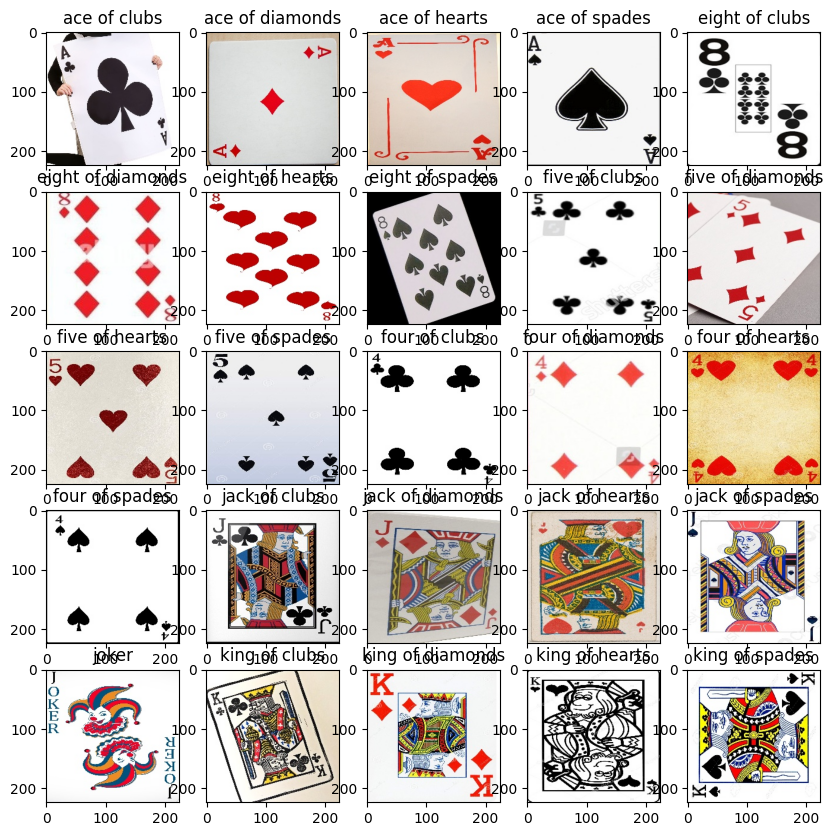

In [3]:
def exploreData (folders) :
    plt.figure(figsize=(10,10))
    for i,fol in tqdm.tqdm(enumerate(folders[:25])) :
        plt.subplot(5,5 ,i+1)
        image = os.listdir(os.path.join(image_dir,fol))[0]
        imgPath = os.path.join(image_dir,fol,image)
        img = cv2.imread(imgPath)
        imgRGB = cv2.cvtColor(img , cv2.COLOR_BGR2RGB)
        imgRGB = cv2.resize(imgRGB, (Sx,Sy))
        plt.title(fol)
        plt.imshow(imgRGB)
    plt.show()
exploreData(train_folders)

In [4]:
x_test_RGB = []
y_test_RGB = []
x_valid_RGB = []
y_valid_RGB = []
x_train_RGB = []
y_train_RGB = []

random.seed(42)

for folder in tqdm.tqdm(train_folders):
    folder_path = os.path.join(image_dir, folder)
    images_in_folder = [os.path.join(folder_path, f) for f in os.listdir(folder_path) if os.path.isfile(os.path.join(folder_path, f))]
    random.shuffle(images_in_folder)

    valid_images = images_in_folder[-test_size:]
    test_images = images_in_folder[:test_size]
    train_images = images_in_folder[:train_size]

    for img_path in test_images:
        img = cv2.imread(img_path)
        imgRGB = cv2.cvtColor(img , cv2.COLOR_BGR2RGB)
        imgRGB = cv2.resize(imgRGB, (Sx,Sy))
        x_test_RGB.append(imgRGB)
        y_test_RGB.append(folder)

    for img_path in valid_images:
        img = cv2.imread(img_path)
        imgRGB = cv2.cvtColor(img , cv2.COLOR_BGR2RGB)
        imgRGB = cv2.resize(imgRGB, (Sx,Sy))
        x_valid_RGB.append(imgRGB)
        y_valid_RGB.append(folder)

    for img_path in train_images:
        img = cv2.imread(img_path)
        imgRGB = cv2.cvtColor(img , cv2.COLOR_BGR2RGB)
        imgRGB = cv2.resize(imgRGB, (Sx,Sy))
        x_train_RGB.append(imgRGB)
        y_train_RGB.append(folder)

x_test_RGB = np.array(x_test_RGB)
x_valid_RGB = np.array(x_valid_RGB)
x_train_RGB = np.array(x_train_RGB)

x_test_RGB = x_test_RGB.astype('float32') / 255.0
x_valid_RGB = x_valid_RGB.astype('float32') / 255.0
x_train_RGB = x_train_RGB.astype('float32') / 255.0

x_test_RGB = x_test_RGB.reshape(-1,Sx,Sy,3)
x_valid_RGB = x_valid_RGB.reshape(-1,Sx,Sy,3)
x_train_RGB = x_train_RGB.reshape(-1,Sx,Sy,3)

df = pd.read_csv('input/cards.csv')
category_labels = df.labels.value_counts().index
categories = {}
for index,cat in enumerate(category_labels) :
  categories[cat]=index

y_train_RGB = [categories[i] for i in y_train_RGB]
y_valid_RGB = [categories[i] for i in y_valid_RGB]
y_test_RGB = [categories[i] for i in y_test_RGB]

y_train_RGB = to_categorical(y_train_RGB)
y_valid_RGB = to_categorical(y_valid_RGB)
y_test_RGB = to_categorical(y_test_RGB)

100%|██████████| 53/53 [00:05<00:00, 10.16it/s]


In [9]:
modelo_5 = Sequential([
    Input(shape=(Sx,Sy,3)),
    Conv2D(64 , (3,3) , activation='relu'),
    MaxPooling2D((2,2)),
    Conv2D(128 , (3,3) , activation='relu'),
    MaxPooling2D((2,2)),
    Conv2D(256 , (3,3) , activation='relu'),
    MaxPooling2D((2,2)),
    Conv2D(512 , (3,3) , activation='relu'),
    MaxPooling2D((2,2)),
    Flatten(),
    Dropout(0.5),
    Dense(256, activation = 'relu'),
    Dropout(0.5),
    Dense(128, activation = 'relu'),
    Dense(64 , activation = 'relu'),
    Dense(53 , activation = 'softmax')
])
modelo_5.compile(optimizer='adam', loss = 'categorical_crossentropy', metrics=['accuracy'])
modelo_5_metrics = modelo_5.fit(x_train_RGB,y_train_RGB,validation_data= (x_valid_RGB,y_valid_RGB), epochs = epocas)

Epoch 1/20
166/166 [==============================] - 29s 174ms/step - loss: 3.9075 - accuracy: 0.0285 - val_loss: 3.3206 - val_accuracy: 0.1547
Epoch 2/20
166/166 [==============================] - 28s 166ms/step - loss: 2.8517 - accuracy: 0.2042 - val_loss: 2.1046 - val_accuracy: 0.3208
Epoch 3/20
166/166 [==============================] - 27s 164ms/step - loss: 1.9024 - accuracy: 0.4077 - val_loss: 1.2427 - val_accuracy: 0.6094
Epoch 4/20
166/166 [==============================] - 29s 173ms/step - loss: 1.3227 - accuracy: 0.5668 - val_loss: 0.8530 - val_accuracy: 0.7406
Epoch 5/20
166/166 [==============================] - 29s 175ms/step - loss: 1.0125 - accuracy: 0.6826 - val_loss: 0.6174 - val_accuracy: 0.8179
Epoch 6/20
166/166 [==============================] - 28s 168ms/step - loss: 0.8305 - accuracy: 0.7421 - val_loss: 0.4637 - val_accuracy: 0.8651
Epoch 7/20
166/166 [==============================] - 26s 160ms/step - loss: 0.6702 - accuracy: 0.7983 - val_loss: 0.3373 - val_ac

In [10]:
modelo_5.evaluate(x_test_RGB, y_test_RGB)

34/34 [==============================] - 1s 33ms/step - loss: 0.0534 - accuracy: 0.9868


[0.053366437554359436, 0.9867924451828003]

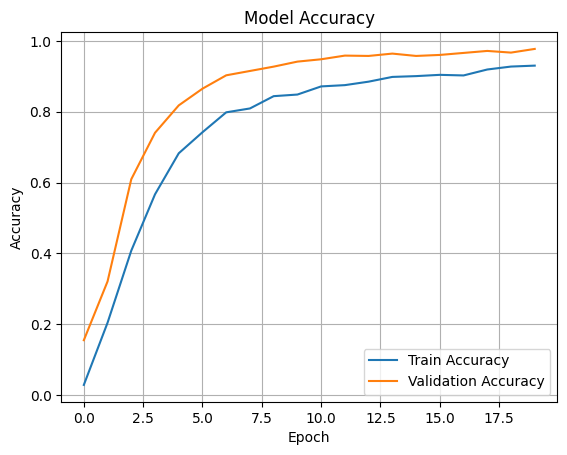

In [11]:
plt.plot(modelo_5_metrics.history['accuracy'], label='Train Accuracy')
plt.plot(modelo_5_metrics.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

34/34 [==============================] - 2s 44ms/step


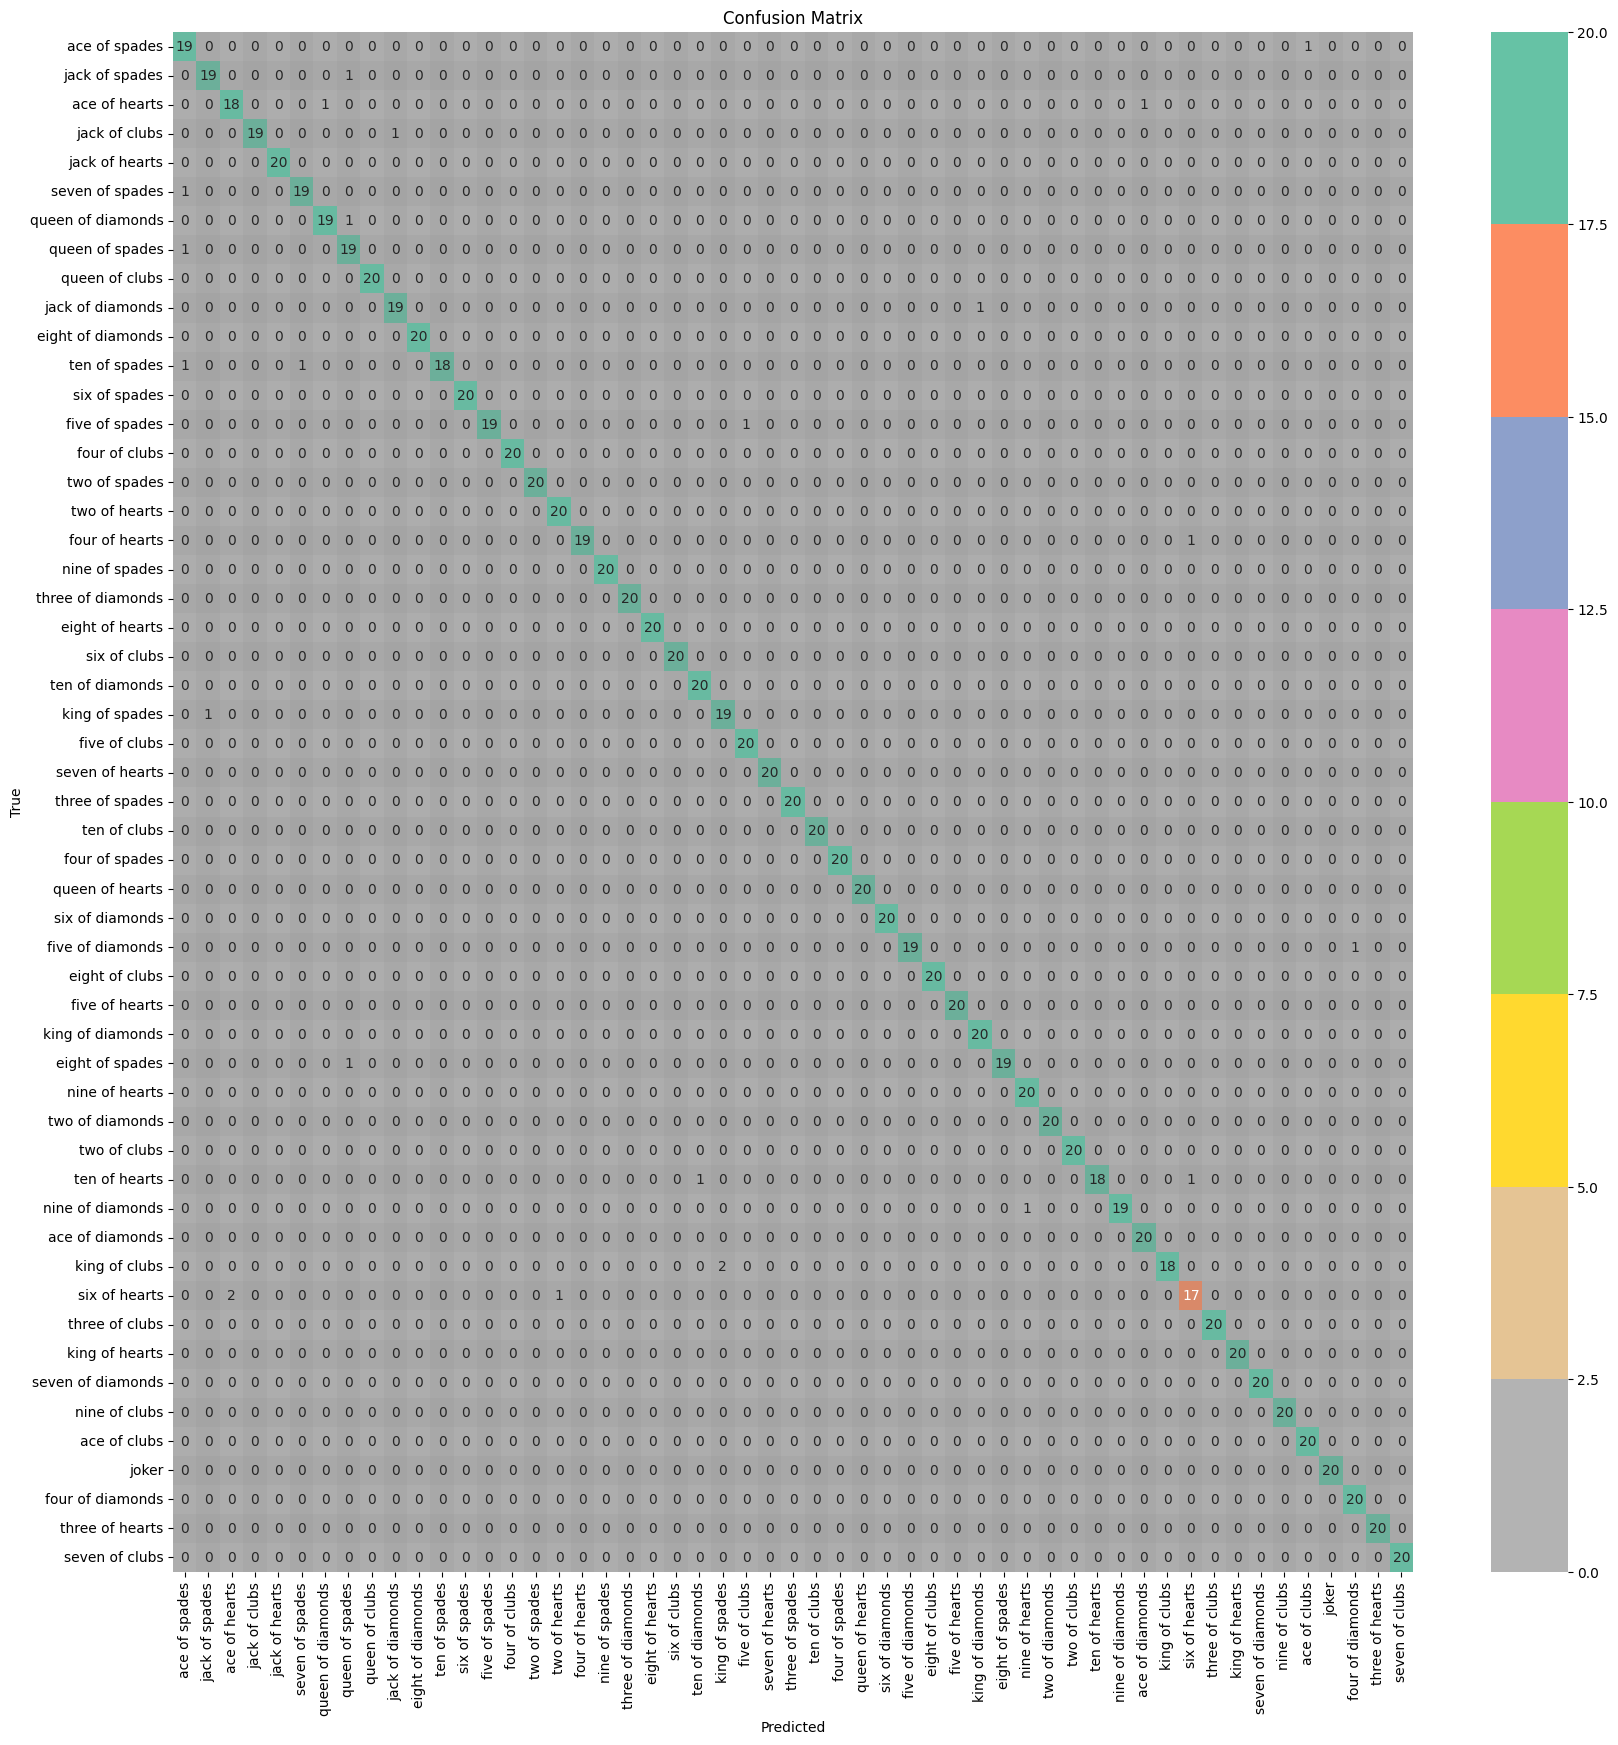

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns

y_pred = modelo_5.predict(x_valid_RGB)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_valid_RGB, axis=1)

cm = confusion_matrix(y_true, y_pred_classes)

id_to_class = {v: k for k, v in categories.items()}
class_names = [id_to_class[i] for i in range(len(id_to_class))]
class_accuracy = np.diag(cm) / np.sum(cm, axis=1)
worst_classes = np.argsort(class_accuracy)[:5]

plt.figure(figsize=(20, 20))
ax = sns.heatmap(cm, annot=True, fmt='d', cmap='Set2_r',
                 xticklabels=class_names, 
                 yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')

num_classes = cm.shape[0]
i = 0
group_count = 0
while i < num_classes:
    a = 0.05 if (group_count % 2 == 0) else 0.15
    ax.add_patch(plt.Rectangle((i, 0), 1, 53, facecolor='gray', alpha=a, edgecolor=None, lw=3, clip_on=False))
    ax.add_patch(plt.Rectangle((0, i), 53, 1, facecolor='gray', alpha=a, edgecolor=None, lw=3, clip_on=False))
    i += 1
    group_count += 1
plt.show()